In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score
import os 
import glob
import math

In [91]:
class Test:
    def __init__(self, df):
        self.df = df
        self.id = df['participant_ID'][0]
        self.date = df['visit_date'][0]
        self.name = f"{self.id}_{self.date}"
        self.df['Stage'] = self.df[self.df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1
        self.df = self.df.set_index('t', drop=False)

        self.lactate_df = self.prepare_lactate_df()

    def prepare_lactate_df(self):
        lactate_df = self.df.dropna(subset='La-')[['La-', 'Phase', 't', 'Speed', 'Grade', 'Stage']]
        lactate_df = lactate_df.drop(lactate_df[lactate_df['La-'] > 20].index)
        lactate_df['log_lactate'] = np.log(lactate_df['La-'])
        lactate_df['log_speed'] = np.log(lactate_df['Speed'])
        return lactate_df

    def lactate_graph(self):
        # Separate logic for graphing
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        self.plot_lactate_reference(axes[0])
        self.plot_lactate_absolute(axes[1])
        plt.tight_layout()
        return plt

    def plot_lactate_reference(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Reference ' + self.name)
        ax.set_ylim(0, None)

        LT1_ref, LT2_ref, _, _ = self.lt_ref_vals()
        if LT1_ref:
            ax.axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            ax.axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def plot_lactate_absolute(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Absolute ' + self.name)
        ax.set_ylim(0, None)

        LT1_abs, LT2_abs, _, _ = self.lt_abs_vals()
        ax.axhline(y=2, color='r', label='Threshold 2 mmol/L')
        ax.axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() >= 0.5)
        lt2ref_index = (self.lactate_df['La-'].diff() >= 1)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 'La-'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 'La-'] if lt2ref_index.any() else None
        LT1ref_speed = self.lactate_df.loc[lt1ref_index.idxmax(), 'Speed'] if lt1ref_index.any() else None
        LT2ref_speed = self.lactate_df.loc[lt2ref_index.idxmax(), 'Speed'] if lt2ref_index.any() else None
        results = {"LT1_ref":LT1ref, "LT2_ref":LT2ref, "LT1ref_speed":LT1ref_speed, "LT2ref_speed":LT2ref_speed}
        return results

    def lt_abs_vals(self):
        lt1abs_index = (self.lactate_df['La-'] >= 2)
        lt2abs_index = (self.lactate_df['La-'] >= 4)
        
        LT1abs = self.lactate_df.loc[lt1abs_index.idxmax(), 'La-'] if lt1abs_index.any() else None
        LT2abs = self.lactate_df.loc[lt2abs_index.idxmax(), 'La-'] if lt2abs_index.any() else None
        LT1abs_speed = self.lactate_df.loc[lt1abs_index.idxmax(), 'Speed'] if lt1abs_index.any() else None
        LT2abs_speed = self.lactate_df.loc[lt2abs_index.idxmax(), 'Speed'] if lt2abs_index.any() else None
        
        results = {
            "LT1_abs": LT1abs, 
            "LT2_abs": LT2abs, 
            "LT1abs_speed": LT1abs_speed, 
            "LT2abs_speed": LT2abs_speed
        }
        return results

    def heart_rate_graph(self):
        fig, ax1 = plt.subplots(figsize=(10, 5))
        exercise_df = self.df[self.df['Phase'] == 'EXERCISE']
        rolling_mean = exercise_df['VO2'].rolling(window=5).mean()

        ax1.plot(exercise_df['t'], rolling_mean, color='blue', label='Heart Rate')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Heart Rate')
        ax1.set_title('Heart Rate and Speed Over Time')
        ax1.grid(True)

        stage_changes = exercise_df[exercise_df['Stage'] != exercise_df['Stage'].shift()]
        stage_times = stage_changes['t']

        for time in stage_times:
            ax1.axvline(x=time, color='red', linestyle='--', alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(exercise_df['t'], exercise_df['Speed'], color='black', linestyle='-', alpha=0.6, label='Speed')
        ax2.set_ylabel('Speed (mph)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')

        lactate_times = self.lactate_df['t'][:-3]
        ax1.set_xticks(lactate_times)

        fig.tight_layout()
        plt.show()

    
    def linear_regression(self, x, y):
        """Perform linear regression and return slope, intercept, and r-value."""
        slope, intercept, r_value, _, _ = linregress(x, y)
        return slope, intercept, r_value
    def find_best_split(self, x, y):
        """Finds the best split point for two linear regression fits and computes the best R²"""
        best_r2_combined = -np.inf
        best_params = None
        if len(x) == 4:
            split_points = [2]  # Only one valid split at index 2
        else:
            split_points = range(2, len(x) - 2)  # Default range for valid splits
        for split in split_points:  
            x_first, y_first = x[:split], y[:split]
            x_last, y_last = x[split:], y[split:]

            # Perform linear regression
            slope_first, intercept_first = np.polyfit(x_first, y_first, 1)
            slope_last, intercept_last = np.polyfit(x_last, y_last, 1)

            # Compute intersection point
            x_intersect, y_intersect = self.compute_intersection(slope_first, intercept_first, slope_last, intercept_last)

            # Predict values for R² calculation
            y_pred_first = slope_first * x_first + intercept_first
            y_pred_last = slope_last * x_last + intercept_last

            # Calculate R² values
            r2_first = r2_score(y_first, y_pred_first)
            r2_last = r2_score(y_last, y_pred_last)

            # Compute weighted R²
            r2_combined = ((len(x_first) * r2_first) + (len(x_last) * r2_last)) / (len(x_first) + len(x_last))

            # Track best split
            if r2_combined > best_r2_combined:
                best_r2_combined = r2_combined
                best_params = (slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last)
        return best_params, best_r2_combined

    def compute_intersection(self, m1, b1, m2, b2):
        """Finds intersection of two lines y = m1*x + b1 and y = m2*x + b2"""
        if m1 == m2:
            return None, None  # Parallel lines, no intersection
        x_intersect = (b2 - b1) / (m1 - m2)
        y_intersect = m1 * x_intersect + b1
        return x_intersect, y_intersect

    def plot_results(self, ax, x, y, params, title, xlabel, ylabel):
        slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last = params

        ax.scatter(x, y, color='black', label='Data')

        # Define x-range for the full span of the graph
        x_min, x_max = min(x), max(x)
        x_range = np.linspace(x_min, x_max, 100)  # Generate a smooth range of x-values

        # Compute y-values for the extended regression lines
        y_first = slope_first * x_range + intercept_first
        y_last = slope_last * x_range + intercept_last

        # Plot the regression lines
        ax.plot(x_range, y_first, 'r-', label=f'Line 1 (R²={r2_first:.2f})')
        ax.plot(x_range, y_last, 'g-', label=f'Line 2 (R²={r2_last:.2f})')

        # Plot the intersection point
        ax.scatter(x_intersect, y_intersect, color='blue', zorder=3, label='Intersection')

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(True)

        # Ensure y-axis starts at 0
        ax.set_ylim(bottom=0)

    def lt_log_semilog(self):
        """Creates LT1 (log-log) and LT2 (semi-log) plots with best two-segment regression fits and intersections"""

        #fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        # === Prepare Data ===
        filtered_df = self.lactate_df.drop_duplicates(subset='Speed', keep='first')
        filtered_df = filtered_df[(filtered_df['Speed'] > 0) & (filtered_df['La-'] > 0)]

        log_speed = np.log(filtered_df['Speed'])
        log_lactate = np.log(filtered_df['La-'])
        speed = filtered_df['Speed']

        # === LT1: Log Speed vs Log Lactate ===
        best_params_lt1, best_r2_combined_lt1 = self.find_best_split(log_speed, log_lactate)
        if best_params_lt1:
            x_intersect_lt1, y_intersect_lt1 = best_params_lt1[4:6]
            lt1_log = math.exp(y_intersect_lt1)
            lt1_log_speed = math.exp(x_intersect_lt1)
            lt1_log_r2 = best_r2_combined_lt1
        else:
            lt1_log = None
            lt1_log_speed = None
            lt1_log_r2 = None
            
        #self.plot_results(axs[0], log_speed, log_lactate, best_params_lt1, 
         #                 'LT1: Log Speed vs Log Lactate', 'Log Speed', 'Log Lactate')

        best_params_lt2, best_r2_combined_lt2 = self.find_best_split(speed, log_lactate)
        if best_params_lt2:
            x_intersect_lt2, y_intersect_lt2 = best_params_lt2[4:6]
            lt2_semilog = x_intersect_lt2
            lt2_semilog_speed = math.exp(y_intersect_lt2)
            lt2_semi_log_r2 = best_r2_combined_lt2
        else:
            lt2_semilog = None
            lt2_semilog_speed = None
            lt2_semi_log_r2 = None

        #self.plot_results(axs[1], speed, log_lactate, best_params_lt2, 
        #                  'LT2: Speed vs Log Lactate', 'Speed', 'Log Lactate')

        plt.tight_layout()
        #plt.show()

        # Extract intersections and convert values

        #print(f"Best LT1 Intersection: ({x_intersect_lt1:.2f}, {y_intersect_lt1:.2f}), Combined R²: {best_r2_combined_lt1:.3f}")
        #print(f"Best LT2 Intersection: ({x_intersect_lt2:.2f}, {y_intersect_lt2:.2f}), Combined R²: {best_r2_combined_lt2:.3f}")

        return {
            "LT1_log":  lt1_log,
            "LT1_log_speed": lt1_log_speed,
            "LT1_log_r2": lt1_log_r2,
            "LT2_semilog": lt2_semilog, 
            "LT2_semilog_speed": lt2_semilog_speed,
            "LT2_semi_log_r2": lt2_semi_log_r2
        } 

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


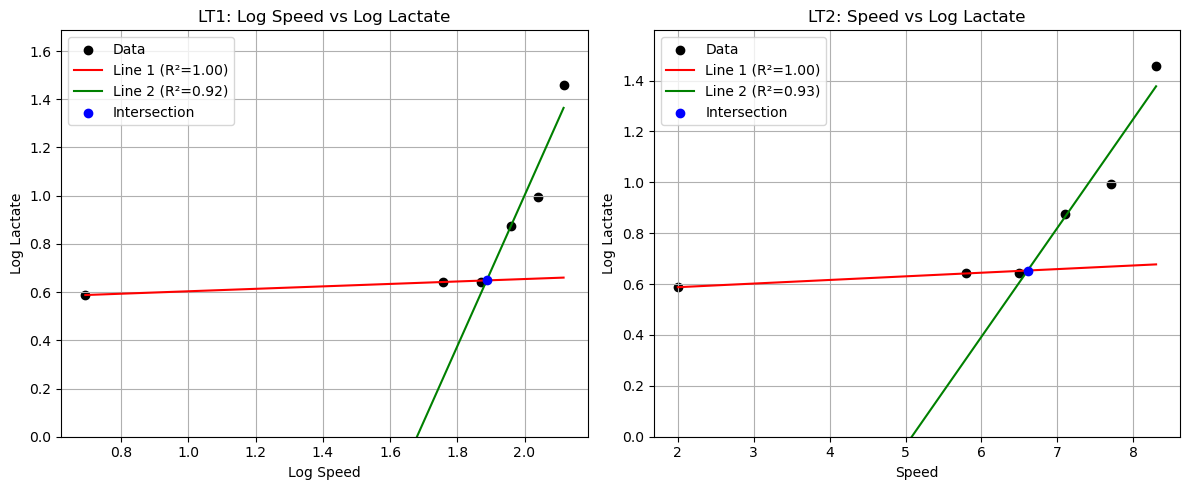

Best LT1 Intersection: (1.89, 0.65), Combined R²: 0.945
Best LT2 Intersection: (6.61, 0.65), Combined R²: 0.954


{'LT1_intersection': (6.601892332230318, 1.9125357177173548),
 'LT2_intersection': (6.6080911124325565, 1.9219716903395),
 'LT1_r2': 0.9448740941574981,
 'LT2_r2': 0.9544814858458106}

In [22]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.lt_log_semilog()

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


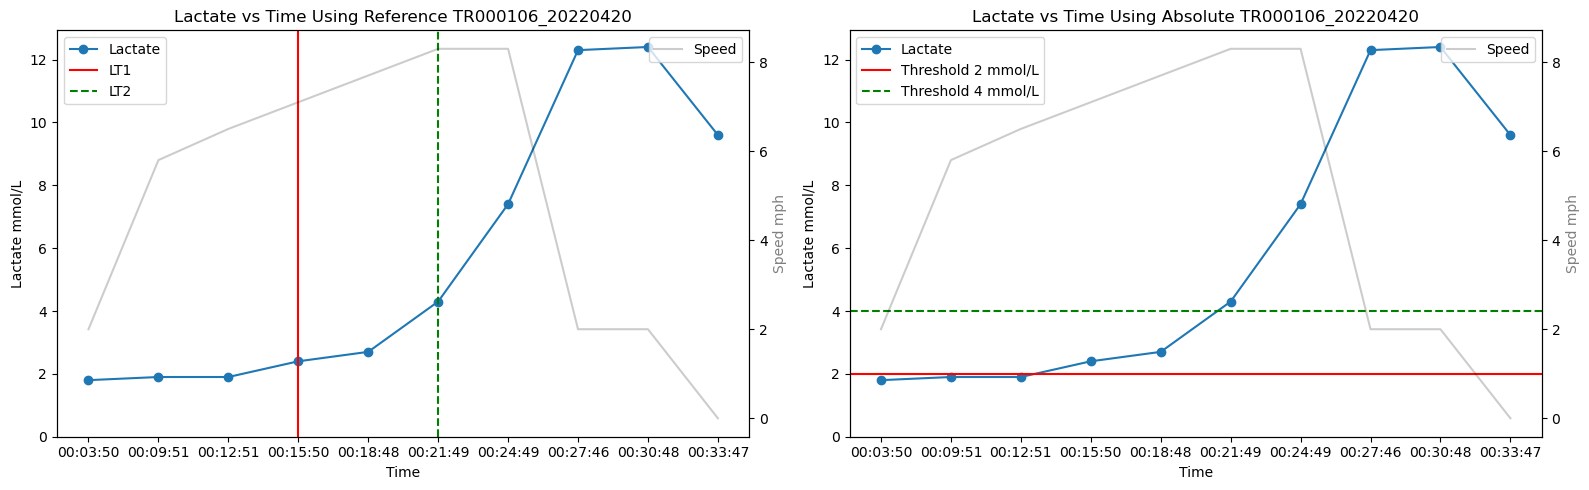

'TR000106_20220420'

In [152]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.lactate_graph()
test.name

In [92]:
import pandas as pd
import glob
import os

path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

results = []
folder_name = "lactate_graphs"

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name
    test_results = test.lt_ref_vals()
    test_results.update(test.lt_abs_vals())
    if test.lt_log_semilog():
        test_results.update(test.lt_log_semilog())
    test_results['Test Name'] = test_name
    
    # Append results to the list
    results.append(test_results)

# Convert results into a DataFrame
results_df = pd.DataFrame(results).set_index('Test Name')

# Display the DataFrame (optional)
results_df

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountere

,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2
Test Name,,,,,,,,,,,,,,
TR000105_20220207,3.6,3.6,4.8,4.8,2.1,4.7,2.0,6.0,3.813462,5.270782,0.627634,5.522174,4.136919,0.605110
TR000106_20220420,2.4,4.3,7.1,8.3,2.4,4.3,7.1,8.3,1.912536,6.601892,0.944874,6.608091,1.921972,0.954481
TR000102_20220204,4.2,4.2,6.8,6.8,3.2,4.2,2.0,6.8,4.720432,11.503199,0.388612,13.179857,6.028641,0.379394
TR000100_20220623,2.5,5.0,8.6,9.8,2.9,5.0,2.0,9.8,2.661080,9.496752,0.791290,9.452235,2.622777,0.787925
TR000104_20220627,3.2,10.4,8.8,8.8,2.6,10.4,2.0,8.8,2.387694,7.471199,0.481254,7.466742,2.377884,0.472052
TR000100_20220331,2.1,3.5,9.2,9.8,2.1,4.1,2.0,2.0,1.873892,8.730868,0.940225,8.730279,1.849370,0.951129
TR000109_20220209,4.1,4.1,6.9,6.9,3.1,4.1,2.0,6.9,2.794752,6.434651,0.894610,6.348056,2.796817,0.908933
TR000107_20220519,3.5,3.5,8.0,8.0,2.1,7.5,2.0,10.5,4.537558,16.183991,0.661123,18.248302,8.375233,0.672879
TR000106_20220208,3.1,5.8,5.8,6.5,2.6,5.8,2.0,6.5,4.539847,58.388586,0.334713,8.322645,5.803316,0.354663


<Figure size 640x480 with 0 Axes>

In [97]:
results_df['LT1/LT2_Ref_same'] = results_df['LT1_ref'] == results_df['LT2_ref']
results_df['LT1/LT2_Abs_same'] = results_df['LT1_abs'] == results_df['LT2_abs']
results_df['LT1_Ref_Abs_same'] = results_df['LT1_ref'] == results_df['LT1_abs']
results_df['LT2_Ref_Abs_same'] = results_df['LT2_ref'] == results_df['LT2_abs']
results_df['LT1log_speed>LT2log_speed'] = results_df['LT1_log_speed'] > results_df['LT2_semilog_speed']
results_df = results_df.sort_index()
results_df


,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2,LT1/LT2_Ref_same,LT1/LT2_Abs_same,LT1_Ref_Abs_same,LT2_Ref_Abs_same,LT1log_speed<LT2log_speed,LT1log_speed>LT2log_speed
Test Name,,,,,,,,,,,,,,,,,,,,
TR000100_20220203,2.7,2.7,8.0,8.0,2.8,4.1,6.7,9.8,3.483946,6.452991,0.817094,6.134018,4.483121,0.769126,True,False,False,False,False,True
TR000100_20220331,2.1,3.5,9.2,9.8,2.1,4.1,2.0,2.0,1.873892,8.730868,0.940225,8.730279,1.849370,0.951129,False,False,True,False,False,True
TR000100_20220623,2.5,5.0,8.6,9.8,2.9,5.0,2.0,9.8,2.661080,9.496752,0.791290,9.452235,2.622777,0.787925,False,False,False,True,False,True
TR000101_20220203,6.1,6.1,7.7,7.7,5.2,5.2,0.0,0.0,9.099884,3.290462,0.943616,0.198815,13.442121,0.947622,True,True,False,False,True,False
TR000101_20220331,3.4,4.8,6.5,8.3,2.6,4.8,2.0,8.3,3.529519,7.660392,1.000000,7.734247,3.659601,1.000000,False,False,False,True,False,True
TR000101_20220630,3.9,3.9,7.7,7.7,2.1,5.3,5.8,8.3,2.317134,7.069872,0.917817,7.094027,2.376535,0.933825,True,False,False,False,False,True
TR000102_20220204,4.2,4.2,6.8,6.8,3.2,4.2,2.0,6.8,4.720432,11.503199,0.388612,13.179857,6.028641,0.379394,True,False,False,True,False,True
TR000102_20220401,3.1,3.1,6.8,6.8,2.0,4.3,2.0,7.4,3.229976,7.626380,0.504272,7.943954,3.441298,0.517382,True,False,False,False,False,True
TR000102_20220630,3.0,3.0,6.8,6.8,3.0,6.9,6.8,9.3,3.115674,8.877255,0.979459,9.150536,3.408498,0.970927,True,False,True,False,False,True
